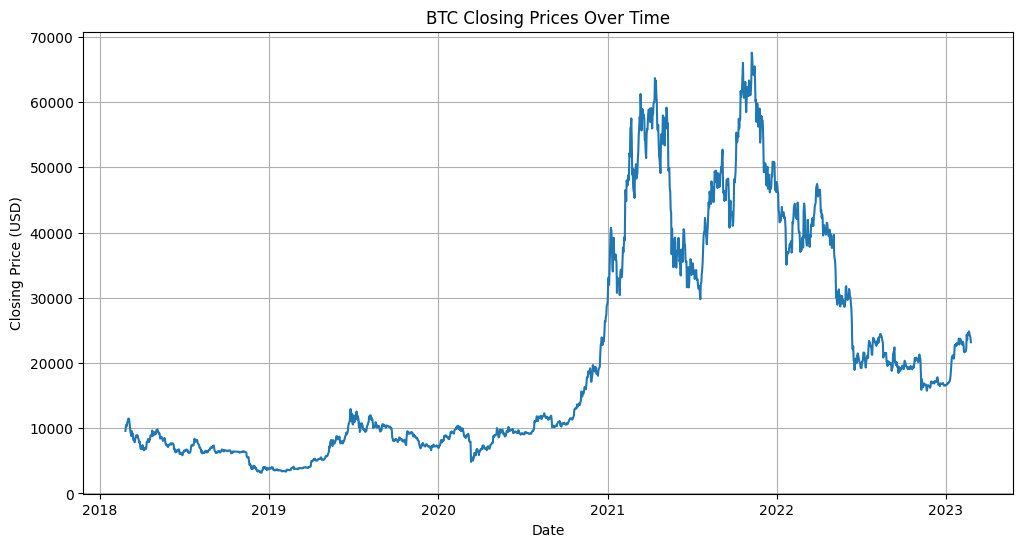

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the BTC.csv file
try:
    df = pd.read_csv('/content/BTC.csv')

    # Convert 'begins_at' column to datetime objects
    df['begins_at'] = pd.to_datetime(df['begins_at'])

    # Plot the closing prices
    plt.figure(figsize=(12, 6))
    plt.plot(df['begins_at'], df['close_price'])
    plt.title('BTC Closing Prices Over Time')
    plt.xlabel('Date')
    plt.ylabel('Closing Price (USD)')
    plt.grid(True)
    plt.show()
    plt.savefig('BTC_Closing_Prices.png')

except FileNotFoundError:
    print("Error: BTC.csv not found. Please make sure the file is uploaded to the /content/ directory.")
except KeyError as e:
    print(f"Error: Missing required column in BTC.csv: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# Load the datasets from the uploaded files
df_baseline = pd.read_csv('predictions_LSTM_Baseline.csv')
df_bert = pd.read_csv('predictions_LSTM_Bert.csv')
df_finbert = pd.read_csv('predictions_LSTM_finBert.csv')
df_llm = pd.read_csv('predictions_LSTM_LLM.csv')

Dataframes have been loaded and aligned.
             true_price  predicted_price
date                                    
2022-04-25  40438.50000        39973.184
2022-04-26  38132.00000        40633.086
2022-04-27  39247.50000        39274.490
2022-04-28  39747.50000        39548.863
2022-04-29  38590.13869        40031.098


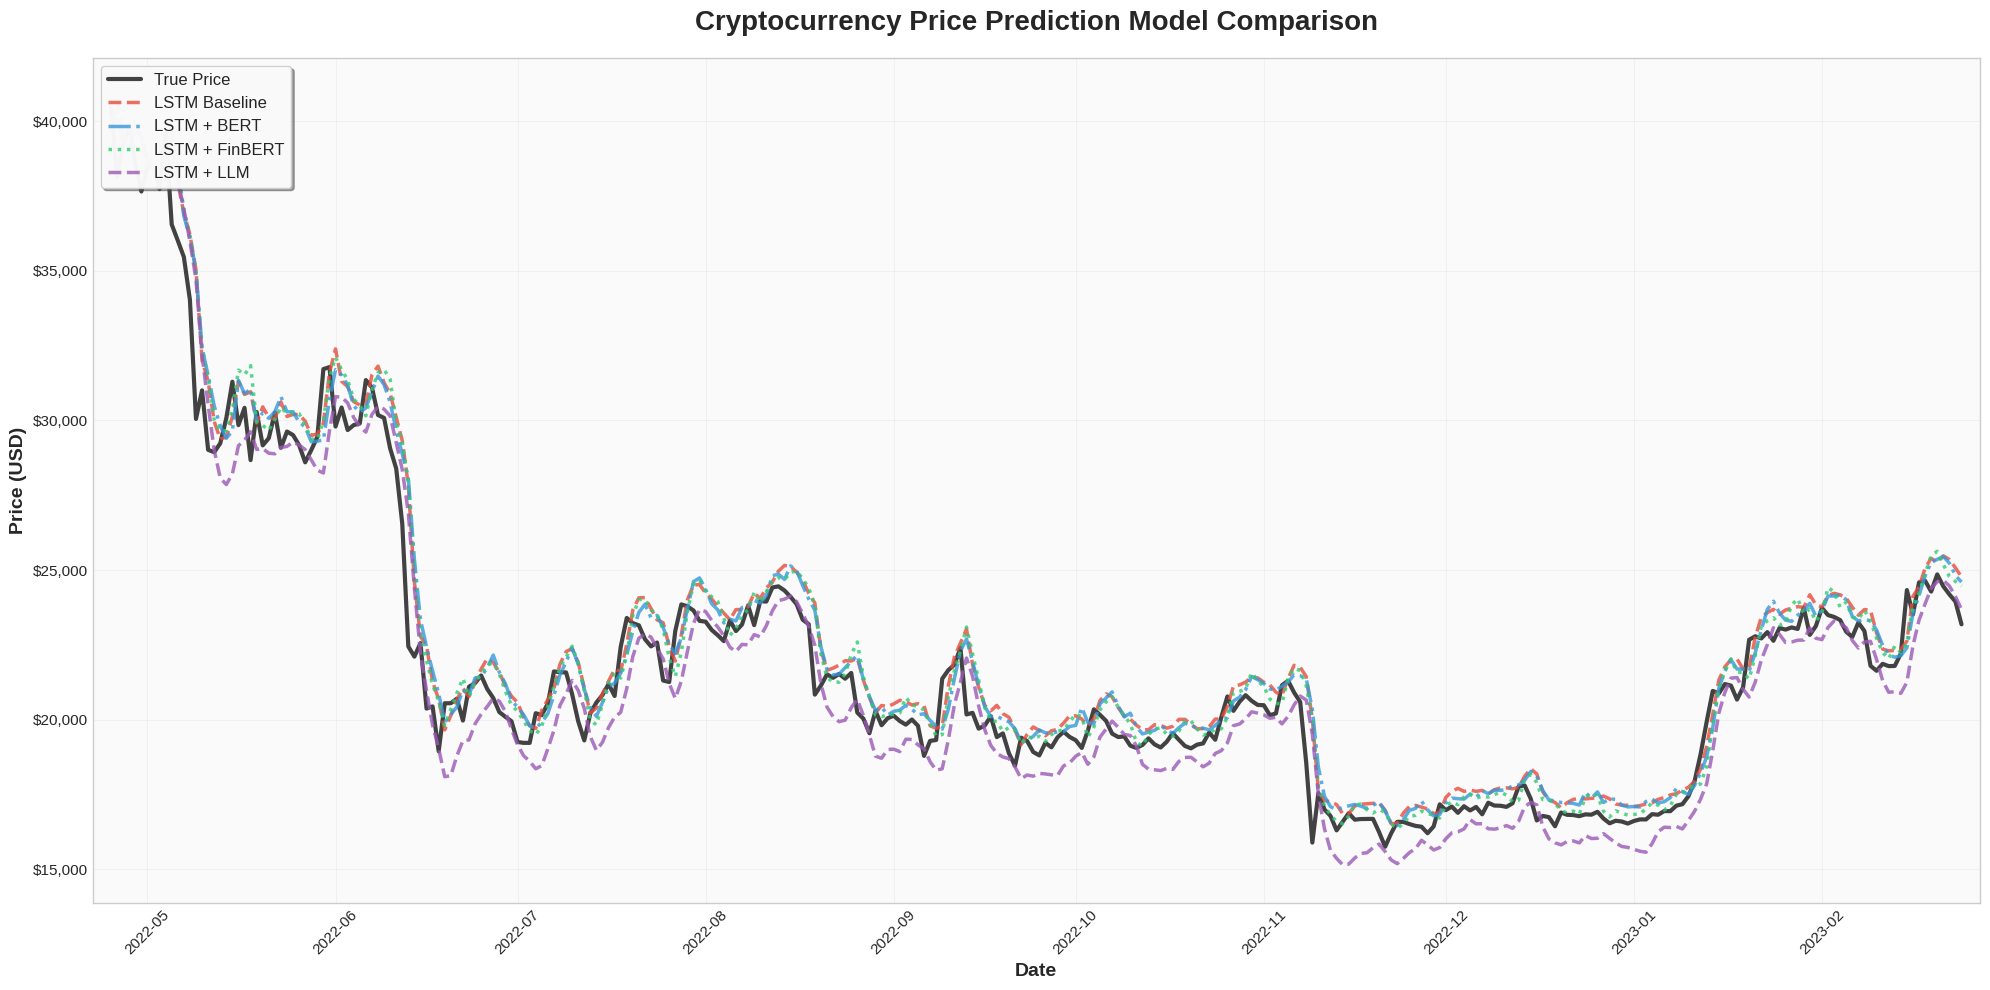


MODEL PERFORMANCE SUMMARY


NameError: name 'np' is not defined

In [14]:
# Convert the 'date' column to datetime and set it as the index for baseline and finbert
df_baseline['date'] = pd.to_datetime(df_baseline['date'])
df_baseline.set_index('date', inplace=True)

df_finbert['date'] = pd.to_datetime(df_finbert['date'])
df_finbert.set_index('date', inplace=True)

# Set the first column as the index for bert and llm
df_bert.set_index(df_bert.columns[0], inplace=True)
df_llm.set_index(df_llm.columns[0], inplace=True)

# Find the minimum length among all dataframes to align them
min_len = min(len(df_baseline), len(df_bert), len(df_finbert), len(df_llm))

# Truncate all dataframes to the minimum length
df_baseline = df_baseline.iloc[:min_len]
df_finbert = df_finbert.iloc[:min_len]
df_bert = df_bert.iloc[:min_len]
df_llm = df_llm.iloc[:min_len]

# Assign the date index from a reference dataframe (e.g., finbert) to bert and llm
df_bert.index = df_finbert.index
df_llm.index = df_finbert.index

print("Dataframes have been loaded and aligned.")
print(df_baseline.head())

# Create the enhanced plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(20, 10))

# Define distinct colors and line styles
colors = {
    'true': '#2E2E2E',      # Dark gray for true price
    'baseline': '#E74C3C',   # Red
    'bert': '#3498DB',       # Blue
    'finbert': '#2ECC71',    # Green
    'llm': '#9B59B6'         # Purple
}

line_styles = {
    'true': '-',
    'baseline': '--',
    'bert': '-.',
    'finbert': ':',
    'llm': '--'
}

# Plot with enhanced styling
ax.plot(df_baseline.index, df_baseline['true_price'],
        label='True Price',
        color=colors['true'],
        linewidth=3,
        alpha=0.9,
        linestyle=line_styles['true'])

ax.plot(df_baseline.index, df_baseline['predicted_price'],
        label='LSTM Baseline',
        color=colors['baseline'],
        linewidth=2.5,
        alpha=0.8,
        linestyle=line_styles['baseline'])

ax.plot(df_bert.index, df_bert['predicted_price'],
        label='LSTM + BERT',
        color=colors['bert'],
        linewidth=2.5,
        alpha=0.8,
        linestyle=line_styles['bert'])

ax.plot(df_finbert.index, df_finbert['predicted_price'],
        label='LSTM + FinBERT',
        color=colors['finbert'],
        linewidth=2.5,
        alpha=0.8,
        linestyle=line_styles['finbert'])

ax.plot(df_llm.index, df_llm['predicted_price'],
        label='LSTM + LLM',
        color=colors['llm'],
        linewidth=2.5,
        alpha=0.8,
        linestyle=line_styles['llm'])

# Enhanced styling
ax.set_title('Cryptocurrency Price Prediction Model Comparison',
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=14, fontweight='bold')

# Improve legend
legend = ax.legend(loc='upper left', fontsize=12, frameon=True,
                   fancybox=True, shadow=True, framealpha=0.95)
legend.get_frame().set_facecolor('white')

# Format x-axis dates
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Add grid customization
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_facecolor('#FAFAFA')

# Add some spacing around the plot
ax.margins(x=0.01, y=0.05)

# Format y-axis to show currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Tight layout
plt.tight_layout()

# Optional: Add a subtle background color difference
fig.patch.set_facecolor('white')

# Display the plot
plt.show()

# Optional: Calculate and display basic metrics
print("\n" + "="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)

models = {
    'Baseline': df_baseline['predicted_price'],
    'BERT': df_bert['predicted_price'],
    'FinBERT': df_finbert['predicted_price'],
    'LLM': df_llm['predicted_price']
}

true_prices = df_baseline['true_price']

for name, predictions in models.items():
    mae = np.mean(np.abs(predictions - true_prices))
    mse = np.mean((predictions - true_prices) ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((true_prices - predictions) / true_prices)) * 100

    print(f"\n{name}:")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAPE: {mape:.2f}%")